# 03 - Real Spotify Million Playlist Dataset

This notebook re-renders the **real-data** results from the CSVs produced by
`experiments/run_real.py`, `experiments/run_taste_real.py` and
`experiments/analyze_real.py`. Nothing is retrained here - we load the saved
tables and redraw the plots. The full setup, scales and analysis are in
[`REAL_RESULTS.md`](../REAL_RESULTS.md).

> Data was streamed directly from the official
> `spotify_million_playlist_dataset.zip` (1M playlists, 66.3M interactions,
> 2.26M unique tracks). Models were trained on a 200k-playlist subsample; see
> the metadata cell below for exact scales.


In [1]:
import os, json
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
REAL = os.path.join('..','results','real')
real = pd.read_csv(os.path.join(REAL,'real_results.csv'))
meta = json.load(open(os.path.join(REAL,'real_meta.json')))
meta


{'n_corpus': 150000,
 'min_count': 8,
 'n_train': 143326,
 'n_test': 6000,
 'n_tracks_catalog': 120851,
 'per_scenario': 250,
 'als_factors': 128,
 'als_iters': 15,
 'seed': 1,
 'k': 500,
 'fit_times': {'popularity': 6.1,
  'item_cf': 47.2,
  'als': 94.5,
  'track2vec': 321.5,
  'title': 10.2,
  'hybrid': 234.8},
 'als_backend': 'implicit',
 'hybrid_reranker': 'lightgbm',
 'features_attached': False,
 'runtime_s': 1593.9}

## 1. Headline comparison (overall, real MPD)


,r_precision,ndcg,clicks
model,,,
item_cf,0.1480,0.2919,5.6944
hybrid,0.1305,0.2765,5.1020
routed_hybrid,0.1287,0.2708,5.4408
als,0.1130,0.2263,8.0744
title,0.0627,0.1299,16.8796
track2vec,0.0582,0.1249,14.1932
popularity,0.0271,0.0715,21.6980


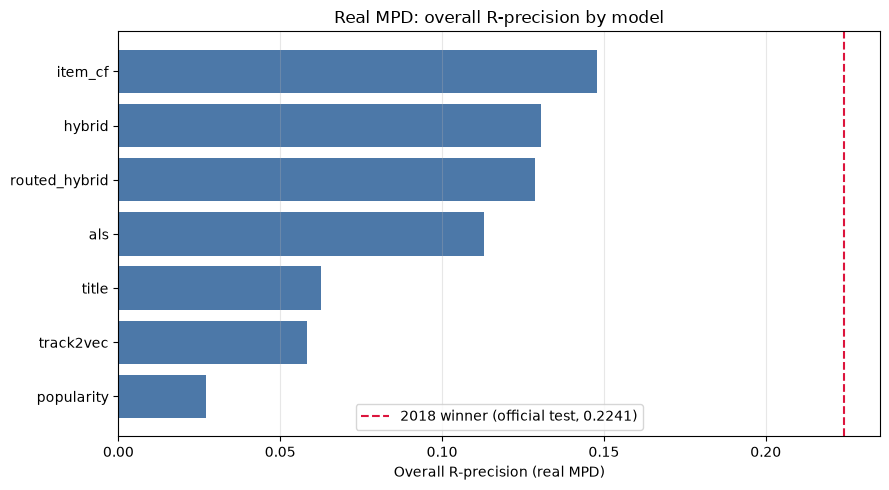

In [2]:
ov = real[real.scenario=='OVERALL'].set_index('model')[['r_precision','ndcg','clicks']]
ov = ov.sort_values('r_precision', ascending=False)
display(ov.round(4))
fig,ax=plt.subplots(figsize=(9,5))
s=ov['r_precision'].sort_values()
ax.barh(s.index, s.values, color='#4C78A8')
ax.set_xlabel('Overall R-precision (real MPD)'); ax.grid(axis='x',alpha=0.3)
ax.axvline(0.2241, ls='--', color='crimson', label='2018 winner (official test, 0.2241)')
ax.legend(); ax.set_title('Real MPD: overall R-precision by model'); plt.tight_layout()


The dashed line is the 2018 challenge winner's **official-test** R-precision
(vl6, 0.2241). Our numbers are on an **internal held-out split** of the public
MPD, so they are not directly comparable - see the caveat in `REAL_RESULTS.md`.


## 2. Per-scenario R-precision heatmap


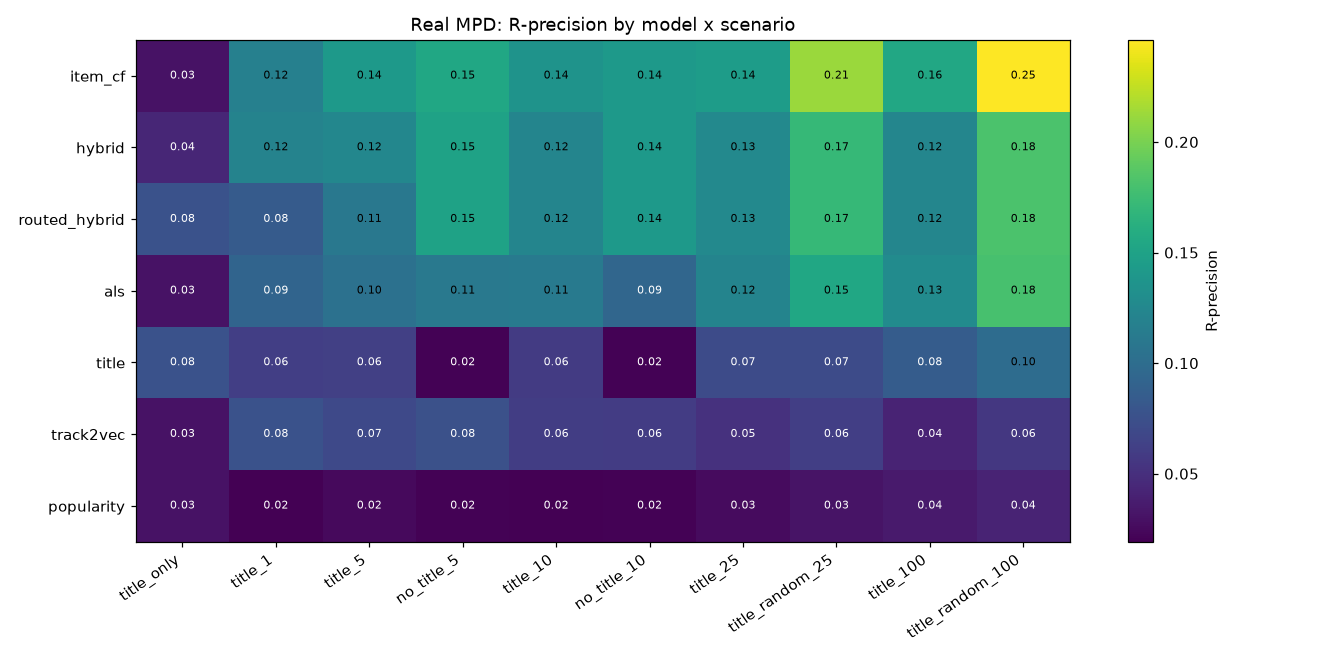

In [3]:
from IPython.display import Image
Image(os.path.join(REAL,'figures','real_scenario_heatmap.png'))


## 3. Which synthetic conclusions held?


In [4]:
held = pd.read_csv(os.path.join(REAL,'held_analysis.csv'))
display(held)


,Synthetic conclusion,Synthetic,Real,Verdict
0,Tier order (overall R-prec),hybrid > als > item_cf > title,item_cf > hybrid > als > title,partial
1,Hybrid >= ALS and item-CF (overall R-prec),yes (0.322 vs 0.311/0.309),NO (0.131 vs 0.113/0.148),didn't hold
2,Routed hybrid > plain hybrid (overall R-prec),"yes (+0.024, 0.379 vs 0.355)","NO (0.129 vs 0.131, -0.002)",didn't hold
3,Title model dominates title_only cold start,yes (0.474 vs 0.193 floor),yes (title 0.076 vs next 0.044),held
4,Routing recovers title_only (routed >> hybrid ...,yes (0.169 -> 0.461),routed 0.076 vs hybrid 0.044,held
5,item-CF top-tier on large random seeds (rand_100),yes (item_cf 0.468 wins),"item_cf 0.246, best=item_cf 0.246",held
6,Track2Vec is the weakest model (overall R-prec),"yes (0.120, worst)",worst = popularity (0.027),didn't hold
7,Taste engine ~ CF pack on R-prec (real audio f...,yes (0.300 vs 0.309 item-CF),taste 0.117 vs item-CF 0.133 on matched subset...,held
8,Popularity is a strong *clicks* baseline,"yes (0.21, synthetic artifact)",popularity clicks 21.70; best=hybrid 5.10,didn't hold


## 4. Synthetic vs real (did the ranking transfer?)


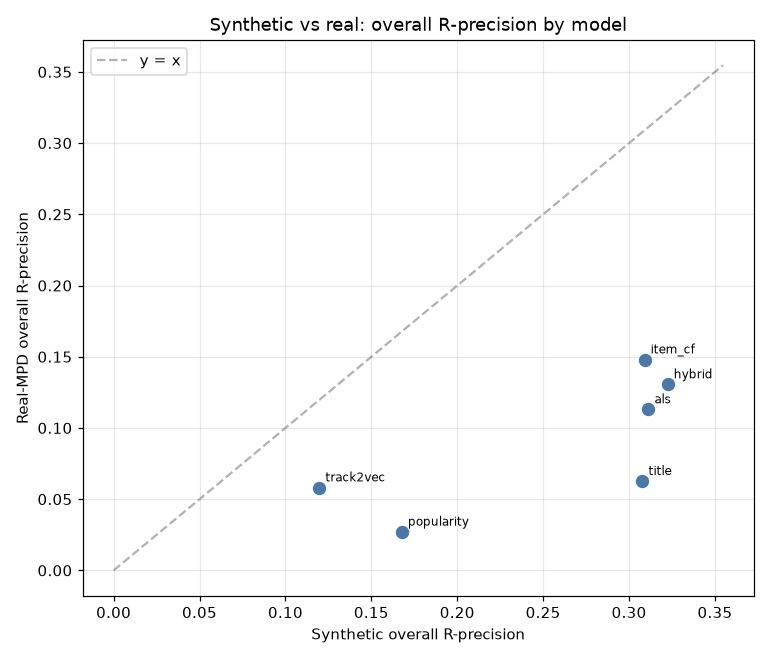

In [5]:
Image(os.path.join(REAL,'figures','real_vs_synthetic_scatter.png'))


## 5. Taste Engine on real audio features (matched subset)

The MPD has no audio features; we joined a public Spotify audio-features table
and evaluated the taste engine on the feature-covered subset. Match rate and
scale are in the metadata below.


In [6]:
tmeta = json.load(open(os.path.join(REAL,'taste_real_meta.json')))
print('audio-feature match rate: %.1f%%' % (100*tmeta['match_rate']))
taste = pd.read_csv(os.path.join(REAL,'taste_real.csv'))
taste[taste.scenario=='OVERALL'].set_index('model')[['r_precision','ndcg','clicks']].round(4)


audio-feature match rate: 43.3%


,r_precision,ndcg,clicks
model,,,
popularity,0.0275,0.0860,22.6742
item_cf,0.1334,0.2833,7.7523
title,0.0602,0.1326,19.1433
taste_engine,0.1168,0.1970,11.7628


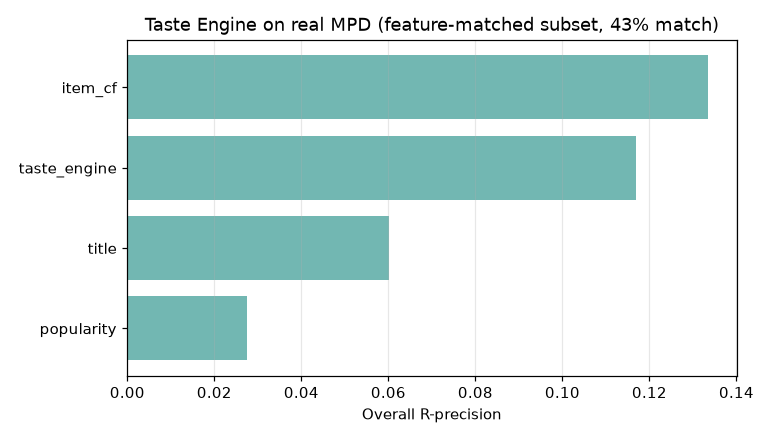

In [7]:
Image(os.path.join(REAL,'figures','real_taste_subset.png'))
